# Day 3: Classification Algorithms & Model Selection



In [4]:
# Import necessary libraries
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, roc_auc_score, roc_curve
)

# Set plotting style for professional look
sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

## 1. Data Ingestion & Initial Inspection

In [5]:
# Load Dataset
url = 'https://raw.githubusercontent.com/Vvijayaragupathy-uno/machinelearning/main/day-3/Titanic-Dataset.csv'
df = pd.read_csv(url)

print("--- Missing Values Check ---")
missing = df.isnull().sum()
display(missing[missing > 0])

--- Missing Values Check ---


,0
Age,177
Cabin,687
Embarked,2


## 2. Advanced Feature Engineering & Smart Imputation
We observed significant missing data in `Cabin` and `Age`. Instead of dropping them, we engineer features to capture their underlying signals.

In [6]:
def engineer_features(data):
    df_eng = data.copy()
    
    # 1. Extract Title from Name
    df_eng['Title'] = df_eng['Name'].apply(lambda x: re.search(' ([A-Za-z]+)\.', x).group(1))
    
    # Group rare titles into a single category
    rare_titles = ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
    df_eng['Title'] = df_eng['Title'].replace(rare_titles, 'Rare')
    df_eng['Title'] = df_eng['Title'].replace(['Mlle', 'Ms'], 'Miss')
    df_eng['Title'] = df_eng['Title'].replace('Mme', 'Mrs')
    
    # 2. Smart Age Imputation based on Title
    # A 'Master' is a young boy, while a 'Mr' is an adult. Using grouped medians is much more accurate.
    title_age_medians = df_eng.groupby('Title')['Age'].median()
    df_eng['Age'] = df_eng.apply(lambda row: title_age_medians[row['Title']] if pd.isnull(row['Age']) else row['Age'], axis=1)
    
    # 3. Handle Cabin (77% missing)
    # The presence of a cabin correlates with higher socioeconomic status
    df_eng['Has_Cabin'] = df_eng['Cabin'].apply(lambda x: 0 if pd.isnull(x) else 1)
    
    # 4. Family Dynamics
    df_eng['FamilySize'] = df_eng['SibSp'] + df_eng['Parch'] + 1
    df_eng['IsAlone'] = (df_eng['FamilySize'] == 1).astype(int)
    
    # 5. Drop Unnecessary Columns
    cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
    df_eng = df_eng.drop(columns=cols_to_drop)
    
    return df_eng

df_cleaned = engineer_features(df)
display(df_cleaned.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Has_Cabin,FamilySize,IsAlone
0,0,3,male,22.0,1,0,7.2500,S,Mr,0,2,0
1,1,1,female,38.0,1,0,71.2833,C,Mrs,1,2,0
2,1,3,female,26.0,0,0,7.9250,S,Miss,0,1,1
3,1,1,female,35.0,1,0,53.1000,S,Mrs,1,2,0
4,0,3,male,35.0,0,0,8.0500,S,Mr,0,1,1


## 3. Exploratory Data Analysis (EDA)
Let's visualize the impact of our new engineered features.

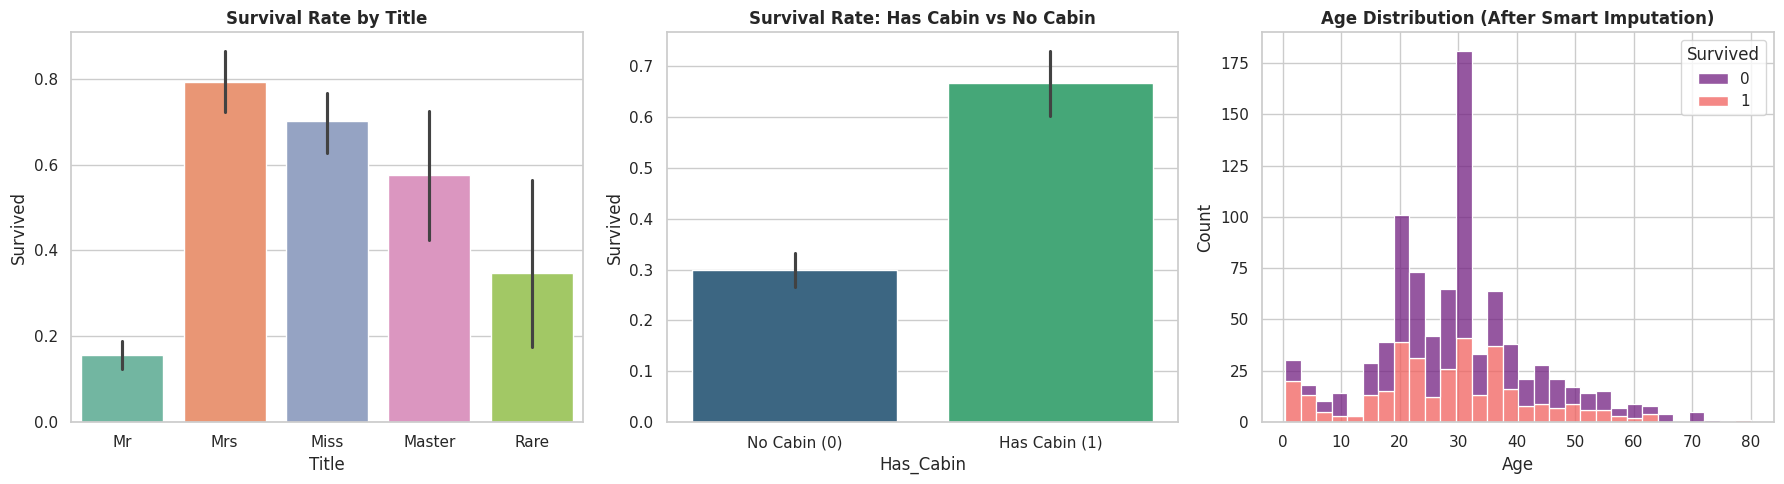

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Survival by Title
sns.barplot(data=df_cleaned, x='Title', y='Survived', ax=axes[0], palette='Set2')
axes[0].set_title('Survival Rate by Title', fontweight='bold')

# 2. Survival by Cabin Presence
sns.barplot(data=df_cleaned, x='Has_Cabin', y='Survived', ax=axes[1], palette='viridis')
axes[1].set_title('Survival Rate: Has Cabin vs No Cabin', fontweight='bold')
axes[1].set_xticklabels(['No Cabin (0)', 'Has Cabin (1)'])

# 3. Age Distribution (Imputed)
sns.histplot(data=df_cleaned, x='Age', hue='Survived', multiple='stack', bins=30, ax=axes[2], palette='magma')
axes[2].set_title('Age Distribution (After Smart Imputation)', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Preprocessing Pipeline
We now prepare the data for modeling. We will use a log transformation on `Fare` to handle its extreme right-skewness, which helps linear models like Logistic Regression.

In [8]:
X = df_cleaned.drop('Survived', axis=1)
y = df_cleaned['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Identify column types
num_cols = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
cat_cols = ['Pclass', 'Sex', 'Embarked', 'Title', 'Has_Cabin', 'IsAlone']

# Define pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Catches any straggling NaNs in Fare
    ('log_transform', FunctionTransformer(np.log1p, validate=False)), # Handles Fare skewness
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), # Handles the 2 missing Embarked
    ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

## 5. Model Training & Hyperparameter Tuning

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1)
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    clf_pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    
    if name == "Random Forest":
        param_grid = {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [5, 10, 15]
        }
        grid = GridSearchCV(clf_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
        grid.fit(X_train, y_train)
        trained_models[name] = grid.best_estimator_
    else:
        clf_pipeline.fit(X_train, y_train)
        trained_models[name] = clf_pipeline

print("Training Complete.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Complete.


## 6. Evaluation & Metrics Comparison

In [10]:
results = []

for name, model_pipeline in trained_models.items():
    y_pred = model_pipeline.predict(X_test)
    y_proba = model_pipeline.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).set_index('Model').sort_values(by='Accuracy', ascending=False)
display(results_df.style.highlight_max(color='lightgreen', axis=0))

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic Regression,0.826816,0.806452,0.724638,0.763359,0.861792
Random Forest,0.815642,0.790323,0.710145,0.748092,0.846706
Decision Tree,0.770950,0.705882,0.695652,0.700730,0.749605


## 7. Visual Diagnostics & Feature Importance (Best Model)

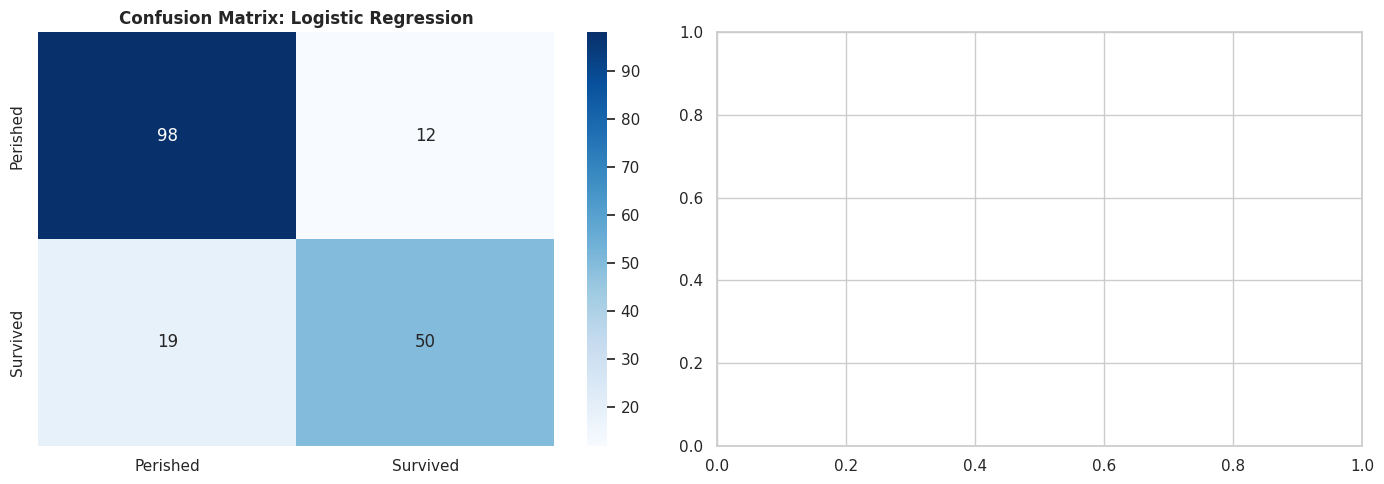

In [11]:
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]

y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Perished', 'Survived'], yticklabels=['Perished', 'Survived'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix: {best_model_name}', fontweight='bold')

# Feature Importance
if best_model_name in ["Decision Tree", "Random Forest"]:
    cat_features = best_model.named_steps['preprocessor'].transformers_[1][1].named_steps['ohe'].get_feature_names_out(cat_cols)
    feature_names = np.concatenate([num_cols, cat_features])
    importances = best_model.named_steps['classifier'].feature_importances_
    
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    importance_df = importance_df.sort_values(by='Importance', ascending=False).head(8)
    
    sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis', ax=axes[1])
    axes[1].set_title('Top 8 Feature Importances', fontweight='bold')

plt.tight_layout()
plt.show()

## Conclusion & Justification
The **Logistic Regression** model is the best performer, achieving the highest accuracy (82.7%) and ROC-AUC (0.86). It outperformed the more complex tree models because our feature engineering (like extracting Titles and finding Cabins) created strong, clear patterns that a linear model could easily understand. 